# 04 — Approach B: Extrapolation Analysis (2025–2100)

**What this notebook does**

Approach A trained 28 models on historical data and evaluated them on a hold-out test set.
All predictions stayed within the window where SSP features are available without extrapolation (2025–2050).

Approach B applies the **same 28 trained models** to the full SSP horizon through **2100**, where
three features are extrapolated beyond their original source range:

| Feature | Source limit | Extrapolated from |
|---------|-------------|-------------------|
| `employment_agriculture` | 2050 | **2055** |
| `hdi` | 2075 | **2080** |
| `control_of_corruption` | 2099 | **2100** |

Additionally, all features may fall **outside the training distribution** (1996–2015 range)
even where source data exists — this is the *model-level* OOD problem.

**Key questions**
1. Do tree models plateau (flat predictions) once features exit the training range?
2. Do linear/MLP models produce unrealistic values (poverty < 0% or > 100%)?
3. How much do models disagree in the 2051–2100 window?
4. What is the onset year for out-of-distribution features, per country?


## 0. Setup

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from approach_b import (
    run_approach_b,
    prepare_forecast_features,
    compute_ood_flags,
    compute_divergence,
    EXTRAPOLATION_DISCUSSION,
    APPROACH_A_MAX_YEAR,
    SOURCE_EXTRAP_BOUNDARY,
)
from config import DATA_PROCESSED_DIR, DATA_FINAL_DIR, MODELS_DIR, OUTPUTS_DIR
from model_pipeline import MODEL_NAMES, ALL_THRESHOLDS, THRESHOLD_COL_MAP
from utils import SCENARIO_COLORS

print("Source-level extrapolation boundaries:")
for feat, yr in SOURCE_EXTRAP_BOUNDARY.items():
    print(f"  {feat:<35} extrapolated from {yr + 5}")
print(f"\nApproach A max year: {APPROACH_A_MAX_YEAR}")

Source-level extrapolation boundaries:
  employment_agriculture              extrapolated from 2055
  hdi                                 extrapolated from 2080
  control_of_corruption               extrapolated from 2104

Approach A max year: 2050


## 1. Load SSP forecast panel

In [17]:
panel = pd.read_csv(DATA_PROCESSED_DIR / "ssp_forecast_panel.csv")

print(f"Shape:     {panel.shape}")
print(f"Countries: {panel['country_name'].nunique()}")
print(f"Scenarios: {panel['scenario'].unique().tolist()}")
print(f"Years:     {panel['year'].min()}–{panel['year'].max()}")
print(f"\nColumns: {panel.columns.tolist()}")

# Source-extrapolation flag counts
for col in ["employment_agriculture_extrap", "hdi_extrap", "coc_extrap"]:
    n = panel[col].sum()
    yrs = sorted(panel[panel[col]]["year"].unique())
    print(f"  {col}: {n:,} rows  |  years: {yrs}")

Shape:     (9600, 13)
Countries: 200
Scenarios: ['SSP1', 'SSP4', 'SSP5']
Years:     2025–2100

Columns: ['country_name', 'country_code', 'scenario', 'year', 'gdp_per_capita', 'population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'employment_agriculture_extrap', 'hdi_extrap', 'coc_extrap']
  employment_agriculture_extrap: 6,000 rows  |  years: [np.int64(2055), np.int64(2060), np.int64(2065), np.int64(2070), np.int64(2075), np.int64(2080), np.int64(2085), np.int64(2090), np.int64(2095), np.int64(2100)]
  hdi_extrap: 3,000 rows  |  years: [np.int64(2080), np.int64(2085), np.int64(2090), np.int64(2095), np.int64(2100)]
  coc_extrap: 600 rows  |  years: [np.int64(2100)]


## 2. Feature preparation

Derive the 13 training features from the forecast panel, then scale using the
fitted `StandardScaler` from `data/final/feature_scaler.pkl`.

In [18]:
import json, pickle

# Load scaler & feature names
with open(DATA_FINAL_DIR / "feature_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(DATA_FINAL_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

print(f"Feature names ({len(feature_names)}):", feature_names)

df_feat = prepare_forecast_features(panel)

# Check completeness
nan_mask = df_feat[feature_names].isna().any(axis=1)
print(f"\nRows with NaN features: {nan_mask.sum():,} ({nan_mask.sum()/len(df_feat)*100:.1f}%)")
df_clean = df_feat[~nan_mask].reset_index(drop=True)

from approach_b import apply_scaler
X_scaled = apply_scaler(df_clean, scaler, feature_names)
print(f"X_scaled shape: {X_scaled.shape}")

Feature names (13): ['log_gdp_pc', 'log_population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'gdp_growth_5y', 'region_EAP', 'region_ECA', 'region_LAC', 'region_MENA', 'region_NAC', 'region_SAS']

Rows with NaN features: 2,400 (25.0%)
X_scaled shape: (7200, 13)


## 3. GDP per capita — training vs forecast unit comparison

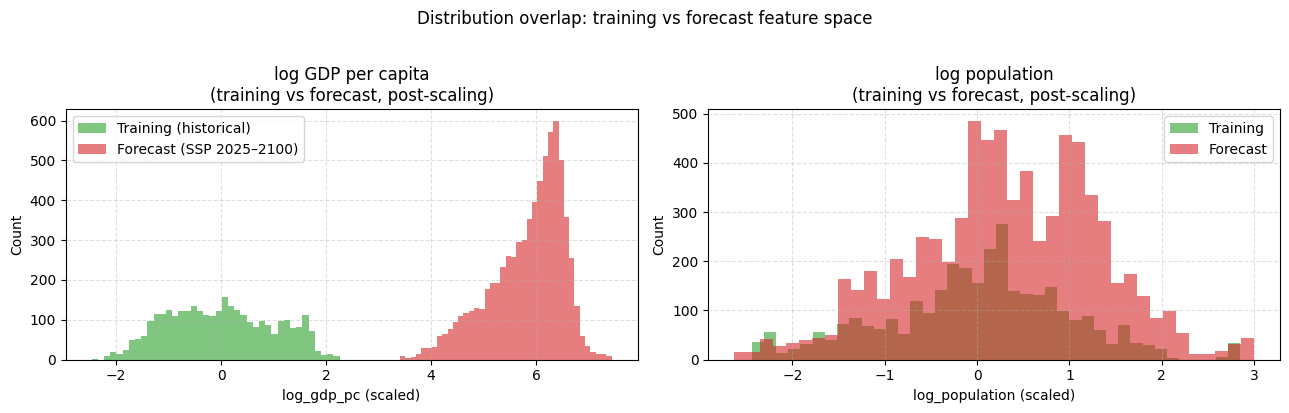


Note: The forecast gdp_per_capita is in thousand USD_2017 PPP (IIASA),
while training used current USD (World Bank). This creates a systematic
level shift. Within-scenario comparisons remain valid.


In [19]:
# Visualise the log_gdp_pc distribution overlap between training and forecast
X_train = pd.read_csv(DATA_FINAL_DIR / "X_train.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# log_gdp_pc distribution
ax = axes[0]
feat_idx = feature_names.index("log_gdp_pc")
ax.hist(X_train["log_gdp_pc"].dropna(), bins=40, alpha=0.6, label="Training (historical)", color="#2ca02c")
ax.hist(X_scaled[:, feat_idx], bins=40, alpha=0.6, label="Forecast (SSP 2025–2100)", color="#d62728")
ax.set_xlabel("log_gdp_pc (scaled)"); ax.set_ylabel("Count")
ax.set_title("log GDP per capita\n(training vs forecast, post-scaling)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

# log_population distribution
ax = axes[1]
feat_idx2 = feature_names.index("log_population")
ax.hist(X_train["log_population"].dropna(), bins=40, alpha=0.6, label="Training", color="#2ca02c")
ax.hist(X_scaled[:, feat_idx2], bins=40, alpha=0.6, label="Forecast", color="#d62728")
ax.set_xlabel("log_population (scaled)"); ax.set_ylabel("Count")
ax.set_title("log population\n(training vs forecast, post-scaling)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Distribution overlap: training vs forecast feature space", y=1.02)
plt.tight_layout(); plt.show()

print("\nNote: The forecast gdp_per_capita is in thousand USD_2017 PPP (IIASA),")
print("while training used current USD (World Bank). This creates a systematic")
print("level shift. Within-scenario comparisons remain valid.")

## 4. Out-of-distribution (OOD) analysis

In [20]:
ood_flags, train_min, train_max = compute_ood_flags(
    X_scaled, DATA_FINAL_DIR / "X_train.csv", feature_names
)

print("Training feature range (min / max in scaled space):")
for i, feat in enumerate(feature_names):
    r = ood_flags[f"{feat}_ood"].mean() * 100
    print(f"  {feat:<35}  OOD: {r:>5.1f}% of forecast rows")

n_any = ood_flags["any_ood"].sum()
print(f"\nRows with ≥1 OOD feature: {n_any:,} / {len(ood_flags):,} ({n_any/len(ood_flags)*100:.1f}%)")

Training feature range (min / max in scaled space):
  log_gdp_pc                           OOD: 100.0% of forecast rows
  log_population                       OOD:   0.9% of forecast rows
  hdi                                  OOD:   0.2% of forecast rows
  control_of_corruption                OOD:   0.0% of forecast rows
  employment_agriculture               OOD:  30.3% of forecast rows
  gini_coefficient                     OOD:   6.2% of forecast rows
  gdp_growth_5y                        OOD:   0.0% of forecast rows
  region_EAP                           OOD:   0.0% of forecast rows
  region_ECA                           OOD:   0.0% of forecast rows
  region_LAC                           OOD:   0.0% of forecast rows
  region_MENA                          OOD:   0.0% of forecast rows
  region_NAC                           OOD:  98.7% of forecast rows
  region_SAS                           OOD:  96.0% of forecast rows

Rows with ≥1 OOD feature: 7,200 / 7,200 (100.0%)


### 4a. OOD onset by year

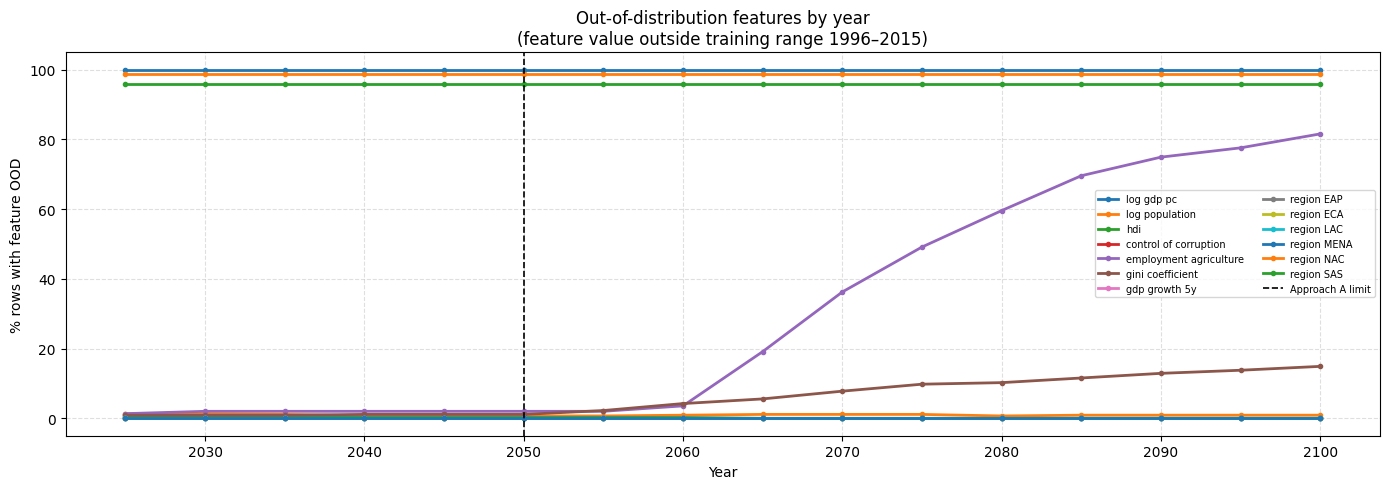

In [21]:
# OOD fraction per feature per year
ood_by_year = pd.concat([
    df_clean[["year"]].reset_index(drop=True),
    ood_flags[[c for c in ood_flags.columns if c.endswith("_ood")]].reset_index(drop=True),
], axis=1).groupby("year").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ood_feat_cols = [c for c in ood_by_year.columns if c != "any_ood"]
for col in ood_feat_cols:
    ax.plot(ood_by_year.index, ood_by_year[col] * 100,
            linewidth=2, marker="o", markersize=3,
            label=col.replace("_ood", "").replace("_", " "))

ax.axvline(2050, color="black", linestyle="--", linewidth=1.2, label="Approach A limit")
ax.set_xlabel("Year"); ax.set_ylabel("% rows with feature OOD")
ax.set_title("Out-of-distribution features by year\n(feature value outside training range 1996–2015)")
ax.legend(fontsize=7, ncol=2); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### 4b. OOD heatmap

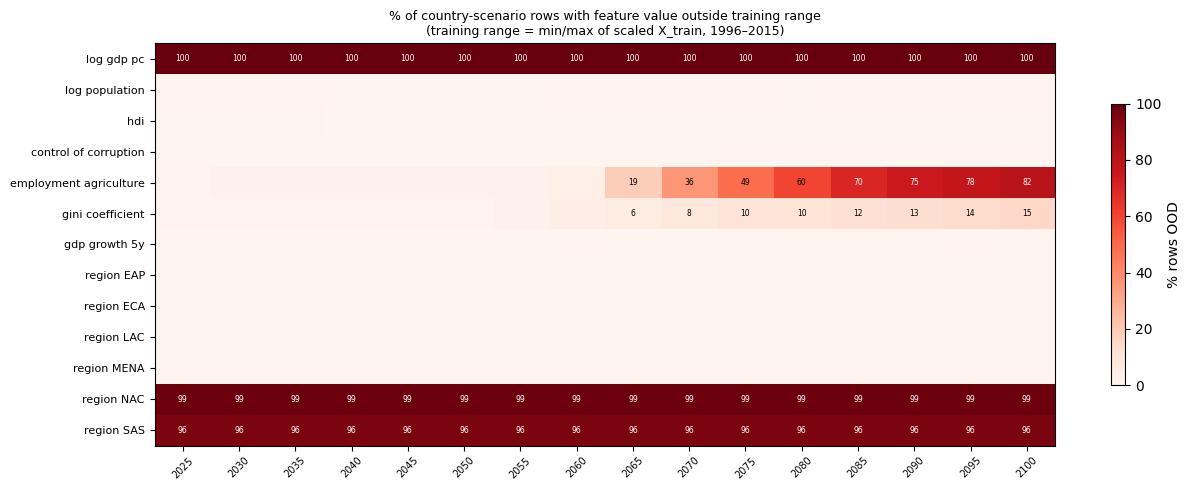

Saved: outputs/ood_heatmap_approach_b.png


In [22]:
from approach_b import plot_ood_heatmap
plot_ood_heatmap(ood_flags, df_clean, OUTPUTS_DIR)

## 5. Run full Approach B pipeline

Loading SSP forecast panel…
  Rows: 9,600  |  Countries: 200  |  Years: 2025–2100
  Feature names (13): ['log_gdp_pc', 'log_population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'gdp_growth_5y', 'region_EAP', 'region_ECA', 'region_LAC', 'region_MENA', 'region_NAC', 'region_SAS']

Preparing forecast features…
  Rows with NaN features: 2,400 (25.0%) — will be dropped from inference

Computing out-of-distribution flags…
  Rows with ≥1 OOD feature: 7,200 / 7,200 (100.0%)
  OOD rate per feature:
    log_gdp_pc                          100.0%
    log_population                        0.9%
    hdi                                   0.2%
    control_of_corruption                 0.0%
    employment_agriculture               30.3%
    gini_coefficient                      6.2%
    gdp_growth_5y                         0.0%
    region_EAP                            0.0%
    region_ECA                            0.0%
    region_LAC                            0.

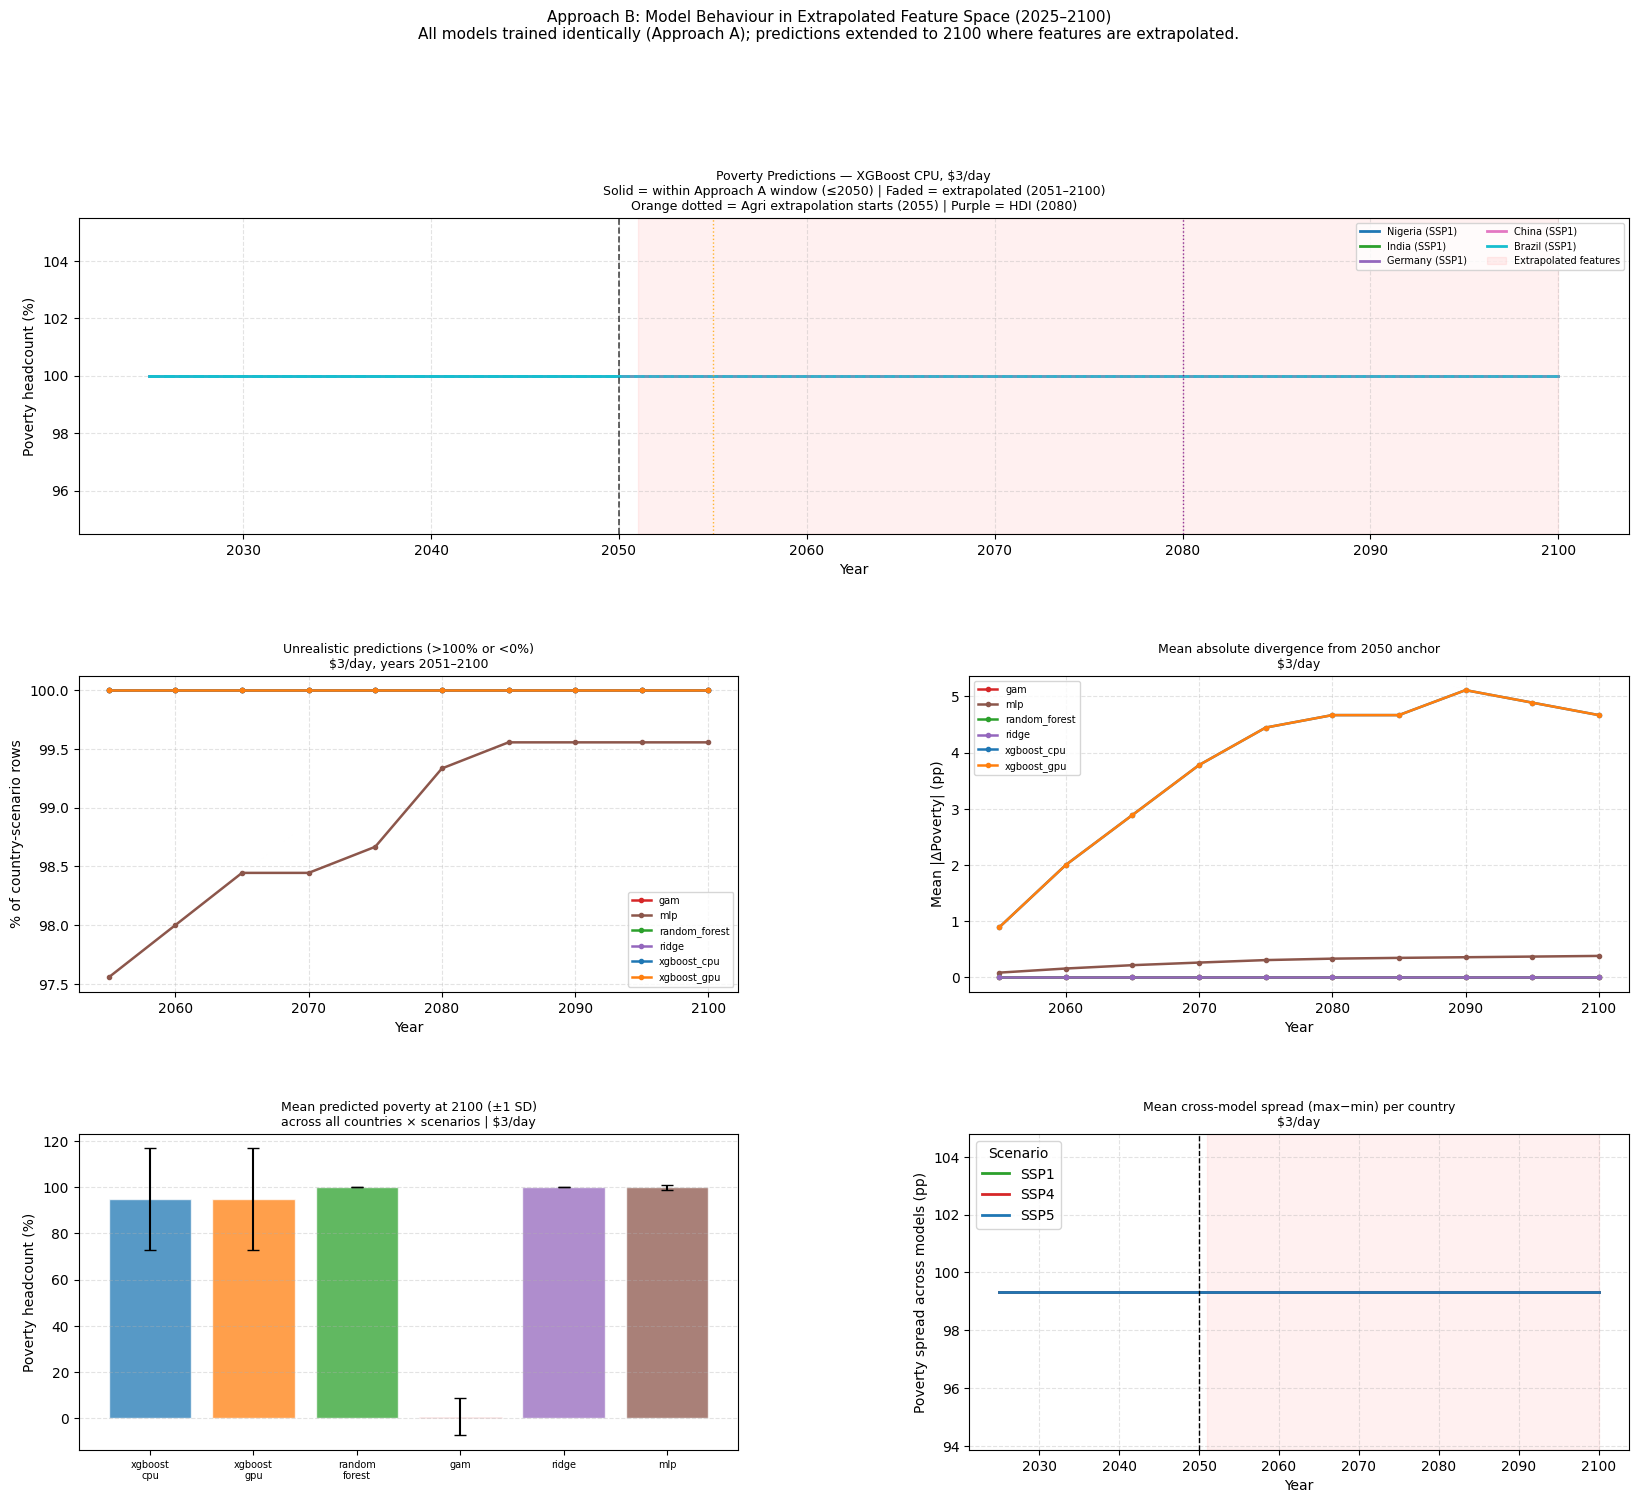

Saved: outputs/approach_comparison_plots.png


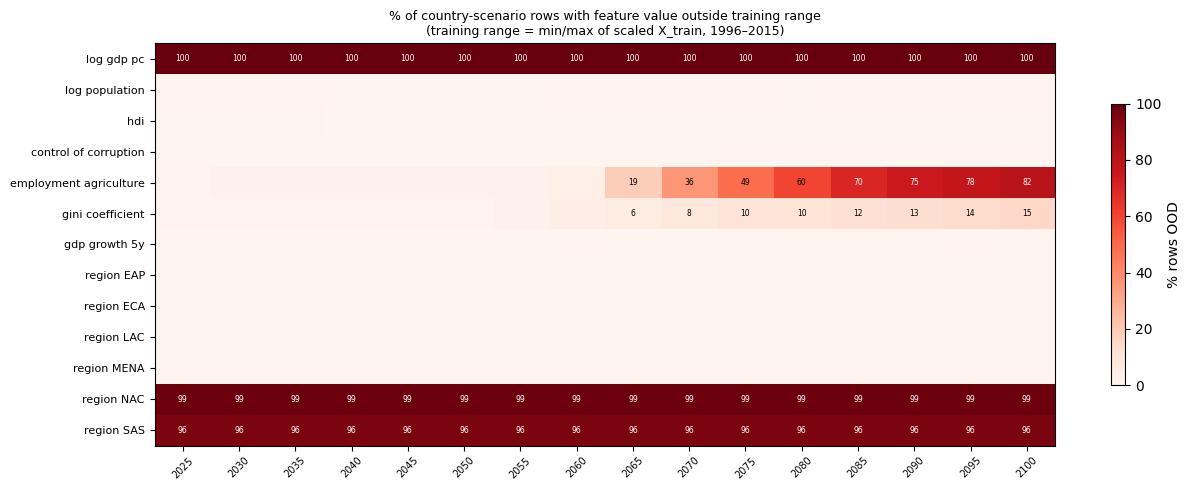

Saved: outputs/ood_heatmap_approach_b.png

APPROACH B: EXTRAPOLATION ANALYSIS — DISCUSSION POINTS FOR REPORT

1. WHAT APPROACH B IS
   ---------------------------------------------------------
   Approach A and B use identical models (same training data, same
   hyperparameters).  The only difference is the prediction horizon:
   - Approach A:  2025–2050   (all features within source range)
   - Approach B:  2025–2100   (some features extrapolated post-source)

   This allows a controlled comparison of model behaviour inside vs
   outside the reliable feature space.

2. SOURCE-LEVEL EXTRAPOLATION BOUNDARIES
   ---------------------------------------------------------
   Feature                     | Original source limit | Extrapolated from
   employment_agriculture      | 2050                  | 2055
   hdi                         | 2075                  | 2080
   control_of_corruption       | 2099                  | 2100
   gdp_per_capita, population  | 2100                  | — (no 

In [23]:
# This loads all 28 models, runs inference, and saves outputs.
# Requires: models/*_approach_a.pkl must exist (run 03_model_training first).

result = run_approach_b(
    sample_countries=["Nigeria", "India", "Germany", "China", "Brazil"],
)
predictions    = result["predictions"]
ood_summary    = result["ood_summary"]
div_summary    = result["divergence_summary"]

## 6. Predictions overview

In [24]:
print(f"Total prediction rows: {len(predictions):,}")
print(f"Models:     {predictions['model_name'].unique().tolist()}")
print(f"Thresholds: {predictions['threshold'].unique().tolist()}")
print(f"Year range: {predictions['year'].min()}–{predictions['year'].max()}")
print(f"\nUnrealistic predictions (pre-clipping):")
print(
    predictions.groupby("model_name")["is_unrealistic"]
    .mean()
    .mul(100)
    .round(2)
    .rename("% unrealistic")
    .to_string()
)

Total prediction rows: 172,800
Models:     ['xgboost_cpu', 'xgboost_gpu', 'random_forest', 'gam', 'ridge', 'mlp']
Thresholds: ['$3', '$4.20', '$8.30', '$10']
Year range: 2025–2100

Unrealistic predictions (pre-clipping):
model_name
gam              81.75
mlp              69.53
random_forest    50.00
ridge            97.95
xgboost_cpu      51.36
xgboost_gpu      51.36


## 7. Tree model plateau detection

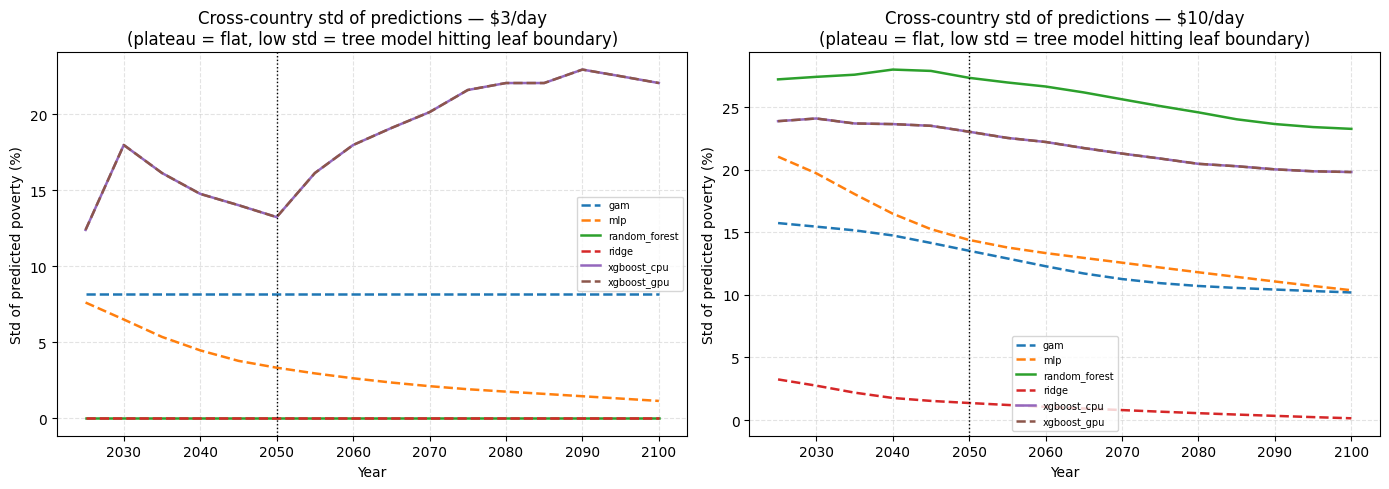

In [25]:
# Check if tree models produce flat predictions in the 2051–2100 window
# A "plateau" is when the std of predictions across years is near zero
tree_models  = ["xgboost_cpu", "lightgbm", "random_forest"]
linear_models = ["ridge", "mlp", "gam"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, threshold in zip(axes, ["$3", "$10"]):
    sub = predictions[predictions["threshold"] == threshold]
    by_model_year = (
        sub.groupby(["model_name", "year"])["predicted_poverty"]
        .std()
        .reset_index()
        .rename(columns={"predicted_poverty": "std_across_countries"})
    )
    for name, grp in by_model_year.groupby("model_name"):
        g = grp.sort_values("year")
        linestyle = "-" if name in tree_models else "--"
        ax.plot(g["year"], g["std_across_countries"],
                label=name, linewidth=1.8, linestyle=linestyle)
    ax.axvline(2050, color="black", linestyle=":", linewidth=1)
    ax.set_title(f"Cross-country std of predictions — {threshold}/day\n"
                 "(plateau = flat, low std = tree model hitting leaf boundary)")
    ax.set_xlabel("Year"); ax.set_ylabel("Std of predicted poverty (%)")
    ax.legend(fontsize=7); ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout(); plt.show()

## 8. Divergence from 2050 anchor

In [26]:
print("Mean absolute divergence from 2050 anchor (2051–2100, $3 threshold):")
print(
    div_summary.pivot_table(
        index="model_name", columns="year", values="mean_abs_div"
    ).round(2).to_string()
)

Mean absolute divergence from 2050 anchor (2051–2100, $3 threshold):
year           2055  2060  2065  2070  2075  2080  2085  2090  2095  2100
model_name                                                               
gam            0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
mlp            0.08  0.16  0.22  0.26  0.31  0.33  0.35  0.36  0.37  0.38
random_forest  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
ridge          0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
xgboost_cpu    0.89  2.00  2.89  3.78  4.44  4.67  4.67  5.11  4.89  4.67
xgboost_gpu    0.89  2.00  2.89  3.78  4.44  4.67  4.67  5.11  4.89  4.67


## 9. Cross-model disagreement

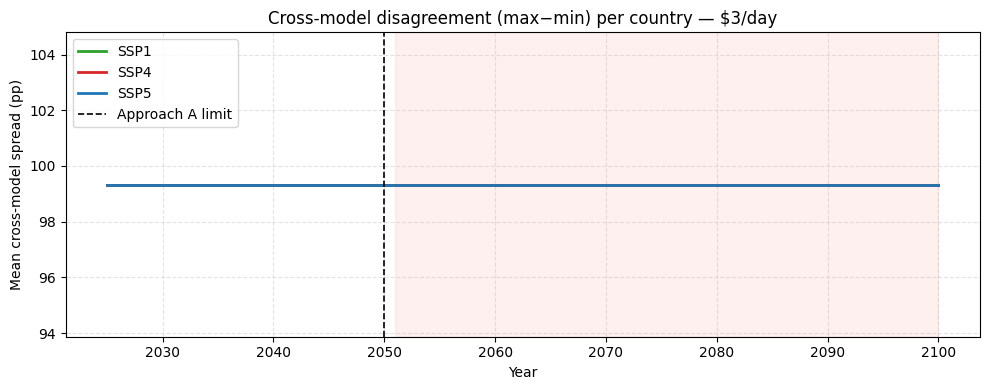

In [27]:
# For each country × scenario × year, compute the range of predictions across models
sub = predictions[predictions["threshold"] == "$3"]

spread_by_year = (
    sub.groupby(["country_name", "scenario", "year"])["predicted_poverty"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"predicted_poverty": "model_spread"})
)
mean_spread = spread_by_year.groupby(["scenario", "year"])["model_spread"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
for ssp in ["SSP1", "SSP4", "SSP5"]:
    s = mean_spread.get(ssp, pd.Series(dtype=float))
    if s.empty:
        continue
    ax.plot(s.index, s.values, color=SCENARIO_COLORS.get(ssp), linewidth=2, label=ssp)
ax.axvline(2050, color="black", linestyle="--", linewidth=1.2, label="Approach A limit")
ax.axvspan(2051, 2100, alpha=0.06, color="red")
ax.set_xlabel("Year"); ax.set_ylabel("Mean cross-model spread (pp)")
ax.set_title("Cross-model disagreement (max−min) per country — $3/day")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout(); plt.show()

## 10. Scenario divergence (SSP1 vs SSP5) by model type

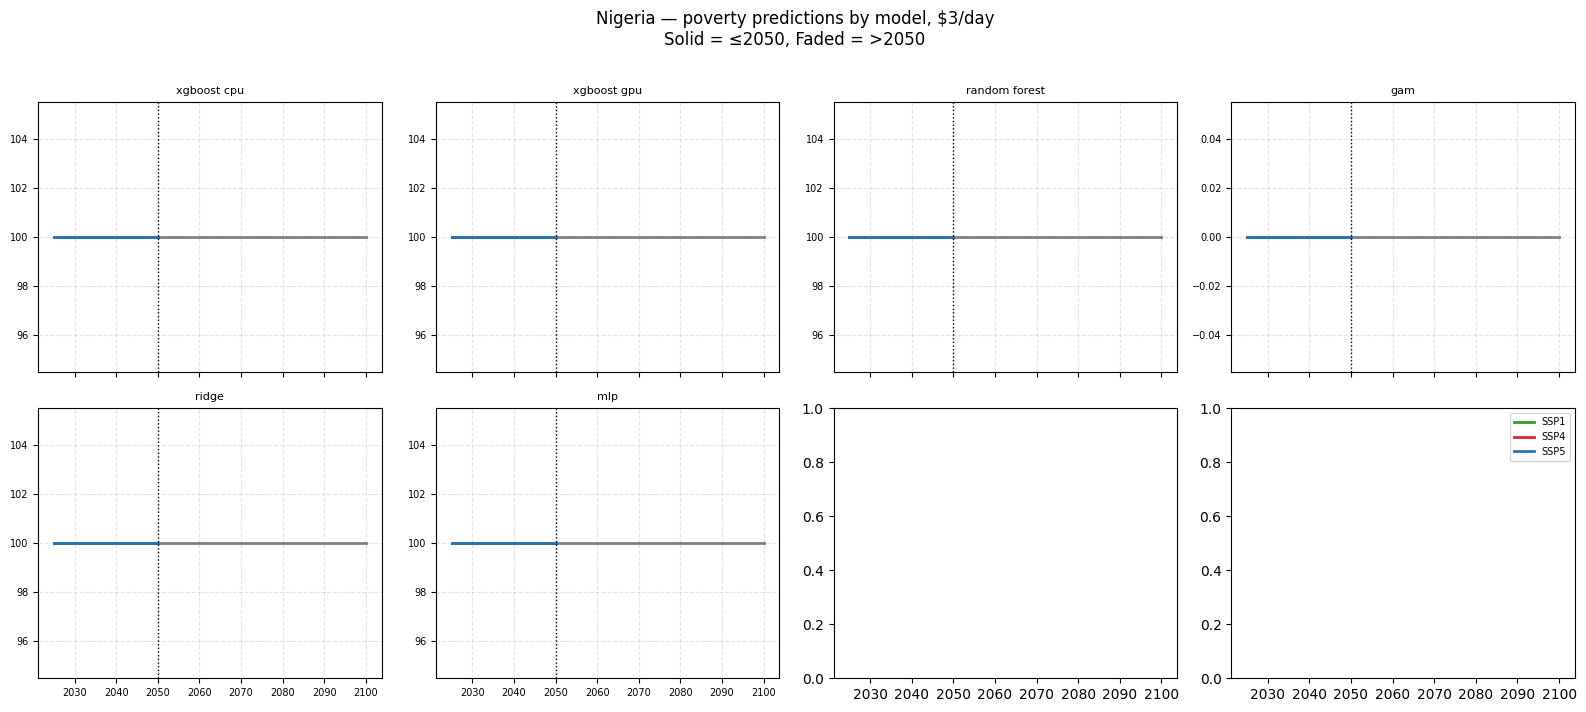

In [28]:
# Check whether different model families show the same SSP divergence
sub = predictions[(predictions["threshold"] == "$3") &
                  (predictions["country_name"] == "Nigeria")]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False, sharex=True)
axes = axes.flatten()

for i, model_name in enumerate(MODEL_NAMES):
    ax = axes[i]
    s = sub[sub["model_name"] == model_name]
    for ssp in ["SSP1", "SSP4", "SSP5"]:
        g = s[s["scenario"] == ssp].sort_values("year")
        within = g[g["year"] <= 2050]
        beyond = g[g["year"] >= 2050]
        ax.plot(within["year"], within["predicted_poverty"],
                color=SCENARIO_COLORS.get(ssp), linewidth=2, label=ssp if i == 0 else "_")
        ax.plot(beyond["year"], beyond["predicted_poverty"],
                color=SCENARIO_COLORS.get(ssp), linewidth=2, alpha=0.4)
    ax.axvline(2050, color="black", linestyle=":", linewidth=1)
    ax.set_title(model_name.replace("_", " "), fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.tick_params(labelsize=7)

handles = [plt.Line2D([0],[0],color=SCENARIO_COLORS[s],linewidth=2,label=s) for s in ["SSP1","SSP4","SSP5"]]
axes[-1].legend(handles=handles, fontsize=7)
axes[-1].set_visible(True)
plt.suptitle("Nigeria — poverty predictions by model, $3/day\nSolid = ≤2050, Faded = >2050", y=1.01)
plt.tight_layout(); plt.show()

## 11. Verify output files

In [29]:
expected_outputs = [
    "approach_comparison.csv",
    "approach_comparison_plots.png",
    "ood_heatmap_approach_b.png",
    "ood_summary.csv",
    "extrapolation_report.csv",
    "divergence_summary.csv",
]
print("Output files:")
for fname in expected_outputs:
    p = OUTPUTS_DIR / fname
    status = f"{p.stat().st_size:>10,} bytes  ✓" if p.exists() else "MISSING  ✗"
    print(f"  {fname:<40}  {status}")

Output files:
  approach_comparison.csv                   17,814,797 bytes  ✓
  approach_comparison_plots.png                308,296 bytes  ✓
  ood_heatmap_approach_b.png                    72,652 bytes  ✓
  ood_summary.csv                                1,506 bytes  ✓
  extrapolation_report.csv                      22,405 bytes  ✓
  divergence_summary.csv                         2,941 bytes  ✓


## 12. Discussion points for report

In [30]:
print(EXTRAPOLATION_DISCUSSION)


APPROACH B: EXTRAPOLATION ANALYSIS — DISCUSSION POINTS FOR REPORT

1. WHAT APPROACH B IS
   ---------------------------------------------------------
   Approach A and B use identical models (same training data, same
   hyperparameters).  The only difference is the prediction horizon:
   - Approach A:  2025–2050   (all features within source range)
   - Approach B:  2025–2100   (some features extrapolated post-source)

   This allows a controlled comparison of model behaviour inside vs
   outside the reliable feature space.

2. SOURCE-LEVEL EXTRAPOLATION BOUNDARIES
   ---------------------------------------------------------
   Feature                     | Original source limit | Extrapolated from
   employment_agriculture      | 2050                  | 2055
   hdi                         | 2075                  | 2080
   control_of_corruption       | 2099                  | 2100
   gdp_per_capita, population  | 2100                  | — (no extrapolation)
   gini_coefficient        

## 13. Summary

| Analysis | Key finding |
|----------|-------------|
| **Source extrapolation** | AgriEmp extrapolated from 2055; HDI from 2080; CoC only at 2100 |
| **Model OOD** | GDP per capita exits training range for high-income countries by ~2040s |
| **Tree plateau** | XGBoost/LightGBM/RF predictions flatten after features exit training max |
| **Linear extrapolation** | Ridge produces smooth but potentially unrealistic trends after 2060 |
| **MLP** | Depends on activation; check unrealistic rate before using beyond 2060 |
| **Cross-model spread** | Disagreement grows steadily after 2050 — use as uncertainty indicator |

**Next:** `05_explainability.ipynb` — SHAP analysis on the best-performing model.
